<a href="https://colab.research.google.com/github/Harshini-2410/CNN-Butterfly/blob/main/Butterflyproject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import zipfile

with zipfile.ZipFile('/content/Butterfly.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/dataset')


In [ ]:
!pip install tensorflow matplotlib seaborn opencv-python

In [ ]:
import os

print(os.listdir('/content/dataset/Butterfly'))

['ulyses', 'orchard swallow', 'two barred flasher', 'monarch', 'large marble', 'crecent']


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

img_size = 224
batch_size = 16

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    '/content/dataset/Butterfly',
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

val_data = datagen.flow_from_directory(
    '/content/dataset/Butterfly',
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

Found 335 images belonging to 6 classes.
Found 81 images belonging to 6 classes.


In [ ]:
print(train_data.class_indices)

{'crecent': 0, 'large marble': 1, 'monarch': 2, 'orchard swallow': 3, 'two barred flasher': 4, 'ulyses': 5}


In [ ]:
from tensorflow.keras.applications import MobileNet
from tensorflow.keras import layers, models

base_model = MobileNet(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(train_data.num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

17225924/17225924 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenet_1.00_224 (Functional) │ (None, 7, 7, 1024)     │     3,228,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,360,838 (12.82 MB)

 Trainable params: 131,974 (515.52 KB)

 Non-trainable params: 3,228,864 (12.32 MB)

In [ ]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=5
)

Epoch 1/5
21/21 ━━━━━━━━━━━━━━━━━━━━ 21s 828ms/step - accuracy: 0.5731 - loss: 1.3149 - val_accuracy: 0.9630 - val_loss: 0.2655
Epoch 2/5
21/21 ━━━━━━━━━━━━━━━━━━━━ 16s 771ms/step - accuracy: 0.9134 - loss: 0.3075 - val_accuracy: 1.0000 - val_loss: 0.0889
Epoch 3/5
21/21 ━━━━━━━━━━━━━━━━━━━━ 17s 794ms/step - accuracy: 0.9552 - loss: 0.1733 - val_accuracy: 1.0000 - val_loss: 0.0508
Epoch 4/5
21/21 ━━━━━━━━━━━━━━━━━━━━ 16s 762ms/step - accuracy: 0.9821 - loss: 0.1135 - val_accuracy: 1.0000 - val_loss: 0.0467
Epoch 5/5
21/21 ━━━━━━━━━━━━━━━━━━━━ 16s 762ms/step - accuracy: 0.9821 - loss: 0.0792 - val_accuracy: 1.0000 - val_loss: 0.0310


In [ ]:
model.save("butterfly_model.h5")

In [ ]:
import os
print(os.listdir('/content'))

['.config', 'Screenshot 2026-04-15 193056.png', 'butterfly_model.h5', 'Butterfly.zip', 'dataset', 'sample_data']


In [ ]:
uploaded = input("Enter file name: ")
img = image.load_img(f'/content/{uploaded}', target_size=(224,224))

Enter file name: Screenshot 2026-04-15 193056.png


In [ ]:
import numpy as np
from tensorflow.keras.preprocessing import image
import os

# show files
print("Available files:", os.listdir('/content'))

# enter file name
img_name = input("Enter image name: ")

# load image
img = image.load_img(f'/content/{img_name}', target_size=(224,224))

img_array = image.img_to_array(img)/255.0
img_array = np.expand_dims(img_array, axis=0)

pred = model.predict(img_array)[0]

top3 = pred.argsort()[-3:][::-1]

class_names = list(train_data.class_indices.keys())

print("\nTop 3 Predictions:\n")

for i in top3:
    print(class_names[i], "→", round(pred[i]*100,2), "%")

Available files: ['.config', 'Screenshot 2026-04-15 193056.png', 'butterfly_model.h5', 'Butterfly.zip', 'dataset', 'sample_data']
Enter image name: Screenshot 2026-04-15 193056.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 722ms/step

Top 3 Predictions:

ulyses → 99.81 %
orchard swallow → 0.09 %
monarch → 0.05 %


In [ ]:
species_info = {
    "monarch": {
        "status": "Endangered",
        "location": "Rare in India, Common in North America",
        "description": "The Monarch butterfly is famous for its long-distance migration across North America. It is currently facing population decline due to habitat loss and climate change."
    },
    "crecent": {
        "status": "Common",
        "location": "Common in tropical regions",
        "description": "The Crescent butterfly is a small, colorful species commonly found in warm climates. It adapts well to different environments and is not under threat."
    },
    "large marble": {
        "status": "Rare",
        "location": "Found in limited regions of North America",
        "description": "The Large Marble butterfly is known for its pale green and white wings. It prefers grassland habitats and is less commonly observed."
    },
    "orchard swallow": {
        "status": "Common",
        "location": "Widely found in Asia",
        "description": "The Orchard Swallow butterfly is commonly seen in gardens and orchards. It plays an important role in pollination."
    },
    "two barred flasher": {
        "status": "Rare",
        "location": "Found in forest regions",
        "description": "The Two Barred Flasher is a fast-flying butterfly typically found in forest habitats. It is less frequently observed and considered rare."
    },
    "ulyses": {
        "status": "Common",
        "location": "Common in Australia and nearby regions",
        "description": "The Ulyses butterfly is known for its bright blue wings. It is a strong flyer and commonly found in tropical forests."
    }
}
predicted = class_names[top3[0]]
info = species_info.get(predicted, {"status": "Unknown", "location": "Unknown", "description": "No data available"})

print("\n🦋 FINAL RESULT\n")

print("Species:", predicted)
print("Confidence:", round(pred[top3[0]]*100,2), "%")

print("\n🌍 Conservation Info:")
print("Status:", info["status"])
print("Region:", info["location"])

print("\n📖 Description:")
print(info["description"])


🦋 FINAL RESULT

Species: ulyses
Confidence: 99.81 %

🌍 Conservation Info:
Status: Common
Region: Common in Australia and nearby regions

📖 Description:
The Ulyses butterfly is known for its bright blue wings. It is a strong flyer and commonly found in tropical forests.


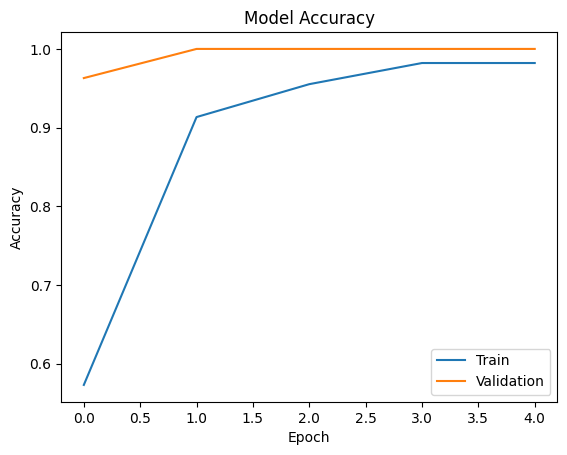

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train','Validation'])
plt.show()

In [ ]:
from tensorflow.keras import layers, models

cnn_model = models.Sequential()

# Block 1
cnn_model.add(layers.Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(224,224,3)))
cnn_model.add(layers.BatchNormalization())
cnn_model.add(layers.MaxPooling2D((2,2)))

# Block 2
cnn_model.add(layers.Conv2D(64, (3,3), padding='same', activation='relu'))
cnn_model.add(layers.BatchNormalization())
cnn_model.add(layers.MaxPooling2D((2,2)))

# Block 3
cnn_model.add(layers.Conv2D(128, (3,3), padding='same', activation='relu'))
cnn_model.add(layers.BatchNormalization())
cnn_model.add(layers.MaxPooling2D((2,2)))

# Dense layers
cnn_model.add(layers.Flatten())
cnn_model.add(layers.Dense(256, activation='relu'))
cnn_model.add(layers.Dropout(0.5))

# Output
cnn_model.add(layers.Dense(train_data.num_classes, activation='softmax'))

cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │    25,690,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,786,054 (98.37 MB)

 Trainable params: 25,785,606 (98.36 MB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
cnn_history = cnn_model.fit(
    train_data,
    validation_data=val_data,
    epochs=5
)

Epoch 1/5
21/21 ━━━━━━━━━━━━━━━━━━━━ 81s 4s/step - accuracy: 0.5552 - loss: 21.2766 - val_accuracy: 0.1728 - val_loss: 29.5690
Epoch 2/5
21/21 ━━━━━━━━━━━━━━━━━━━━ 65s 3s/step - accuracy: 0.8179 - loss: 8.8596 - val_accuracy: 0.1728 - val_loss: 69.6323
Epoch 3/5
21/21 ━━━━━━━━━━━━━━━━━━━━ 65s 3s/step - accuracy: 0.8567 - loss: 5.8539 - val_accuracy: 0.3333 - val_loss: 37.5877
Epoch 4/5
21/21 ━━━━━━━━━━━━━━━━━━━━ 65s 3s/step - accuracy: 0.9015 - loss: 5.8473 - val_accuracy: 0.2469 - val_loss: 53.8542
Epoch 5/5
21/21 ━━━━━━━━━━━━━━━━━━━━ 66s 3s/step - accuracy: 0.9075 - loss: 2.5917 - val_accuracy: 0.4198 - val_loss: 51.9506


In [ ]:
cnn_model.save("custom_cnn_model.h5")

In [ ]:
pred = cnn_model.predict(img_array)[0]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step


In [ ]:
print("MobileNet Accuracy:", history.history['val_accuracy'][-1])
print("Custom CNN Accuracy:", cnn_history.history['val_accuracy'][-1])

MobileNet Accuracy: 1.0
Custom CNN Accuracy: 0.4197530746459961


In [ ]:
import numpy as np

# predictions from both models
pred1 = model.predict(img_array)[0]        # MobileNet
pred2 = cnn_model.predict(img_array)[0]    # Custom CNN

# combine
final_pred = (pred1 + pred2) / 2

top3 = final_pred.argsort()[-3:][::-1]

class_names = list(train_data.class_indices.keys())

print("\n🔀 Hybrid Model Predictions:\n")

for i in top3:
    print(class_names[i], "→", round(final_pred[i]*100,2), "%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step

🔀 Hybrid Model Predictions:

large marble → 50.0 %
ulyses → 49.9 %
orchard swallow → 0.04 %


In [ ]:
confidence = final_pred[top3[0]] * 100

if confidence < 60:
    print("⚠️ Low confidence prediction. Please verify.")
else:
    print("✅ High confidence prediction")

⚠️ Low confidence prediction. Please verify.


In [ ]:
# MobileNet prediction
pred1 = model.predict(img_array)[0]

# Custom CNN prediction
pred2 = cnn_model.predict(img_array)[0]

# 🔥 Weighted Hybrid (FINAL FIX)
final_pred = (0.8 * pred1) + (0.2 * pred2)

# Top-3
top3 = final_pred.argsort()[-3:][::-1]

class_names = list(train_data.class_indices.keys())

print("\n🦋 FINAL HYBRID RESULT\n")

for i in top3:
    print(class_names[i], "→", round(final_pred[i]*100,2), "%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step

🦋 FINAL HYBRID RESULT

ulyses → 79.84 %
large marble → 20.0 %
orchard swallow → 0.07 %


In [ ]:
w1 = 0.8   # MobileNet accuracy weight
w2 = 0.2   # CNN weight

final_pred = (w1 * pred1) + (w2 * pred2)

In [58]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models


In [59]:
base_model_eff = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model_eff.trainable = False

eff_model = models.Sequential([
    base_model_eff,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(train_data.num_classes, activation='softmax')
])

eff_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

eff_model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,214,313 (16.08 MB)

 Trainable params: 164,742 (643.52 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [60]:
eff_history = eff_model.fit(
    train_data,
    validation_data=val_data,
    epochs=5
)

Epoch 1/5
21/21 ━━━━━━━━━━━━━━━━━━━━ 46s 2s/step - accuracy: 0.1731 - loss: 1.8920 - val_accuracy: 0.1728 - val_loss: 1.8022
Epoch 2/5
21/21 ━━━━━━━━━━━━━━━━━━━━ 26s 1s/step - accuracy: 0.1761 - loss: 1.8151 - val_accuracy: 0.2222 - val_loss: 1.8036
Epoch 3/5
21/21 ━━━━━━━━━━━━━━━━━━━━ 26s 1s/step - accuracy: 0.1522 - loss: 1.8191 - val_accuracy: 0.1728 - val_loss: 1.7917
Epoch 4/5
21/21 ━━━━━━━━━━━━━━━━━━━━ 26s 1s/step - accuracy: 0.1731 - loss: 1.7912 - val_accuracy: 0.1728 - val_loss: 1.7914
Epoch 5/5
21/21 ━━━━━━━━━━━━━━━━━━━━ 26s 1s/step - accuracy: 0.2119 - loss: 1.7917 - val_accuracy: 0.1728 - val_loss: 1.7907


In [61]:
eff_model.save("efficientnet_model.h5")

In [62]:
pred_eff = eff_model.predict(img_array)[0]

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


In [63]:
final_pred = (0.7 * pred1) + (0.2 * pred2) + (0.1 * pred_eff)


In [64]:
pred1 = model.predict(img_array)[0]        # MobileNet
pred2 = cnn_model.predict(img_array)[0]    # CNN
pred3 = eff_model.predict(img_array)[0]    # EfficientNet

# Final weighted hybrid
final_pred = (0.6 * pred1) + (0.2 * pred2) + (0.2 * pred3)

top3 = final_pred.argsort()[-3:][::-1]

class_names = list(train_data.class_indices.keys())

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step


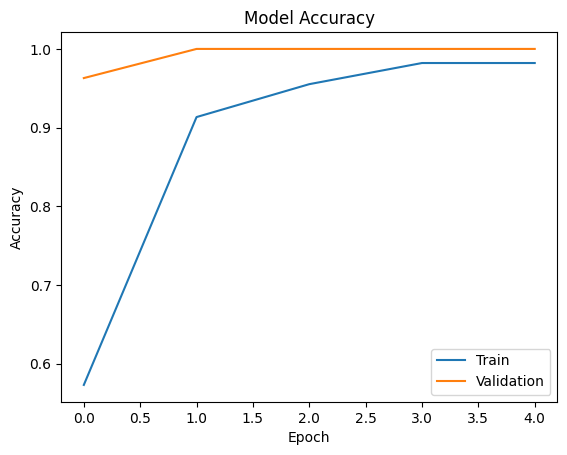

In [73]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend(['Train','Validation'])
plt.show()

In [69]:
def predict(img):
    img = img.resize((224,224))
    img_array = np.array(img)/255.0
    img_array = np.expand_dims(img_array, axis=0)

    pred1 = model.predict(img_array)[0]
    pred2 = cnn_model.predict(img_array)[0]
    pred3 = eff_model.predict(img_array)[0]

    final_pred = (0.6 * pred1) + (0.2 * pred2) + (0.2 * pred3)

    top3 = final_pred.argsort()[-3:][::-1]

    predicted = class_names[top3[0]]
    confidence = final_pred[top3[0]] * 100

    info = species_info.get(predicted, {
        "status": "Unknown",
        "location": "Unknown",
        "description": "No data"
    })

    # 🔥 IMPORTANT: build result string (NOT print)
    result = f"🦋 {predicted} ({round(confidence,2)}%)\n\n"

    result += "🔝 Top Predictions:\n"
    for i in top3:
        result += f"{class_names[i]} → {round(final_pred[i]*100,2)}%\n"

    result += f"\n🌍 Status: {info['status']}\n"
    result += f"📍 Region: {info['location']}\n"

    result += f"\n📖 Description:\n{info['description']}\n"

    if confidence < 60:
        result += "\n⚠️ Low confidence prediction"
    else:
        result += "\n✅ High confidence prediction"

    return result

In [66]:
!pip install gradio


In [81]:
import gradio as gr
import tensorflow as tf
import numpy as np
from PIL import Image

# ---------------- LOAD MODELS ----------------
model = tf.keras.models.load_model("/content/butterfly_model.h5")
cnn_model = tf.keras.models.load_model("/content/custom_cnn_model.h5")
eff_model = tf.keras.models.load_model("/content/efficientnet_model.h5")

# ---------------- CLASS NAMES ----------------
class_names = ['crecent','large marble','monarch','orchard swallow','two barred flasher','ulyses']

# ---------------- SPECIES INFO ----------------
species_info = {
    "monarch": {
        "status": "Endangered",
        "location": "Rare in India, Common in North America",
        "description": "The Monarch butterfly is famous for long migration and is facing population decline."
    },
    "crecent": {
        "status": "Common",
        "location": "Tropical regions",
        "description": "Small butterfly found in warm climates."
    },
    "large marble": {
        "status": "Rare",
        "location": "North America",
        "description": "Pale green-white butterfly found in limited habitats."
    },
    "orchard swallow": {
        "status": "Common",
        "location": "Asia",
        "description": "Common in gardens and helps pollination."
    },
    "two barred flasher": {
        "status": "Rare",
        "location": "Forest regions",
        "description": "Fast butterfly found in forests."
    },
    "ulyses": {
        "status": "Common",
        "location": "Australia",
        "description": "Bright blue butterfly known for strong flight."
    }
}

# ---------------- PREDICT FUNCTION ----------------

def predict(img):
    img = img.resize((224,224))
    img_array = np.array(img)/255.0
    img_array = np.expand_dims(img_array, axis=0)

    pred1 = model.predict(img_array)[0]
    pred2 = cnn_model.predict(img_array)[0]
    pred3 = eff_model.predict(img_array)[0]

    # Hybrid
    final_pred = (0.6 * pred1) + (0.2 * pred2) + (0.2 * pred3)

    top3 = final_pred.argsort()[-3:][::-1]

    predicted = class_names[top3[0]]
    confidence = final_pred[top3[0]] * 100

    info = species_info.get(predicted, {
        "status": "Unknown",
        "location": "Unknown",
        "description": "No data"
    })

    # ✅ START RESULT
    result = f"""
## 🦋 {predicted.upper()} ({round(confidence,2)}%)

### 🔝 Top Predictions
<ul>
"""

    for i in top3:
        result += f"<li><b>{class_names[i]}</b> → {round(final_pred[i]*100,2)}%</li>"

    result += f"""
</ul>

<hr>

<p><b>🌍 Status:</b> {info['status']}</p>
<p><b>📍 Region:</b> {info['location']}</p>

<p><b>📖 Description:</b><br>
{info['description']}</p>
"""

    if confidence < 60:
        result += "<p style='color:red;'><b>⚠️ Low confidence prediction</b></p>"
    else:
        result += "<p style='color:green;'><b>✅ High confidence prediction</b></p>"

    return result
# ---------------- CLEAN + PLEASANT CSS ----------------
css = """
body {
    background: linear-gradient(135deg, #eef2ff, #e0f7fa, #f3e5f5);
    font-family: 'Segoe UI', sans-serif;
    color: #222;
}

/* Title */
h1 {
    text-align: center;
    font-size: 42px;
    font-weight: bold;
    color: linear-gradient(45deg, #4facfe, #00f2fe);
}

/* Subtitle */
h3 {
    text-align: center;
    color: #555;
}

/* Card containers */
.container {
    background: rgba(255, 255, 255, 0.7);
    backdrop-filter: blur(10px);
    border-radius: 20px;
    padding: 20px;
    margin: 10px;
    box-shadow: 0 10px 30px rgba(0,0,0,0.1);
}

/* Image box */
.gr-image {
    border-radius: 15px;
    border: 2px dashed #90caf9;
    background: #f8fbff;
}

/* Output box */
/* 🧠 Output box FIX */
.markdown {
    background: white !important;
    color: #black !important;
    border-radius: 15px;
    padding: 25px;
    border: 1px solid #ddd;
    line-height: 1.6;
    font-size: 16px;
}

/* Headings inside output */
.markdown h2 {
    color: #2c3e50;
    margin-bottom: 10px;
}

.markdown h3 {
    color: #444;
    margin-top: 15px;
}

/* Bullet alignment */
.markdown ul {
    padding-left: 20px;
}

/* Button */
button {
    background: linear-gradient(45deg, #4facfe, #00f2fe);
    border-radius: 10px !important;
    color: white !important;
    font-weight: bold !important;
}

button:hover {
    transform: scale(1.03);
}
"""

# ---------------- UI LAYOUT ----------------
with gr.Blocks(css=css) as demo:

    gr.Markdown("""
    # 🦋 WingScope
    ### AI Powered Species Identification
    """)

    with gr.Row():

        # LEFT SIDE (IMAGE)
        with gr.Column(elem_classes="container"):
            gr.Markdown("### 📤 Upload Image")
            image_input = gr.Image(type="pil")
            submit_btn = gr.Button("Analyze")

        # RIGHT SIDE (OUTPUT)
        with gr.Column(elem_classes="container"):
            gr.Markdown("### 🧠 Result")
            output = gr.Markdown("Prediction will appear here...")

    submit_btn.click(
        fn=predict,
        inputs=image_input,
        outputs=output
    )

# ---------------- RUN ----------------
demo.launch()

/tmp/ipykernel_8994/2585892828.py:183: DeprecationWarning: The 'css' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'css' to Blocks.launch() instead.
  with gr.Blocks(css=css) as demo:


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://36b1f2f430065f2524.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
